In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 18 — Make the pipeline efficient without changing the evidence

Read `lessons/18_lesson.md` and `workbooks/18_workbook.md` first. Predict each result before executing. All outputs here are reference examples, not a grade.

**Evidence boundary:** real static stereo observations are bundled; analytical controls are labeled synthetic. No VGGT checkpoint is run by this notebook.

Source keys: S01, S02

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json, time
import numpy as np
import matplotlib.pyplot as plt
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src/shape_lab").is_dir())
if str(ROOT / "src") not in sys.path: sys.path.insert(0, str(ROOT / "src"))
from shape_lab.stereo import reference_sample, point_cloud, depth_from_disparity
from shape_lab.geometry import *
from shape_lab.display import save_json, show_and_save, plot_diagram
left, right, reference_disparity, calibration = reference_sample()
OUT = ROOT / "reports" / "stage_18"
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(20260920)
print("Real data:", left.shape, right.shape, reference_disparity.shape)
print("Data source:", calibration["source"])

Real data: (500, 741, 3) (500, 741, 3) (500, 741)
Data source: scikit-image 0.26.0 stereo_motorcycle; Middlebury 2014


## 1. Time a real CPU data-processing task
The same real reference-derived point table is transformed by a Python loop and a NumPy array operation. We warm both functions and record several trials. These are this build environment's CPU microbenchmarks—not a camera pipeline, GPU benchmark or hardware recommendation.

Loop CPU time: {'n': 8, 'p50_s': 0.024852732999988802, 'p95_s': 0.02975742344985974, 'max_s': 0.030984016999809683}
Array CPU time: {'n': 8, 'p50_s': 0.0001446085000225139, 'p95_s': 0.000180461249919972, 'max_s': 0.00019787899987022683}


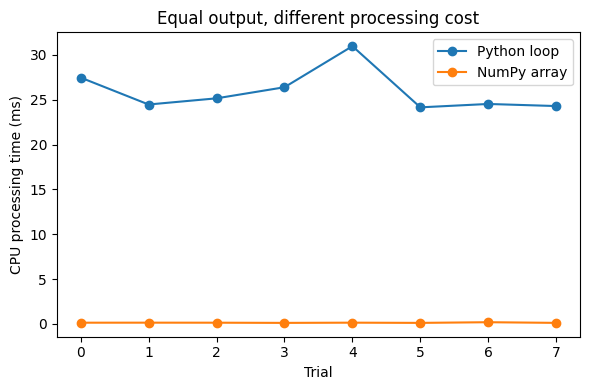

In [3]:
from shape_lab.temporal import fifo_latencies,summarize_latencies
cloud,rc=point_cloud(reference_disparity,calibration,stride=5)
cloud=cloud[:15000];R=exp_so3([.1,.2,-.03]);t=np.array([.1,.2,.3])
def loop_transform(X):
    return np.array([R@p+t for p in X])
def vector_transform(X):
    return X@R.T+t
expected=loop_transform(cloud);actual=vector_transform(cloud)
assert np.allclose(actual,expected)
loop_transform(cloud);vector_transform(cloud)
trace=[]
# Alternate order across trials; report all timings, not a selected fastest trial.
for trial in range(8):
    funcs=[("loop",loop_transform),("array",vector_transform)]
    if trial%2:funcs.reverse()
    for name,fn in funcs:
        start=time.perf_counter();out=fn(cloud);elapsed=time.perf_counter()-start
        assert np.allclose(out,expected)
        trace.append({"trial":trial,"method":name,"seconds":elapsed,"rows":len(cloud)})
loop_s=[x["seconds"] for x in trace if x["method"]=="loop"]
array_s=[x["seconds"] for x in trace if x["method"]=="array"]
print("Loop CPU time:",summarize_latencies(loop_s))
print("Array CPU time:",summarize_latencies(array_s))
import csv
with (OUT / "cpu_trace.csv").open("w",newline="") as f:
    writer=csv.DictWriter(f,fieldnames=list(trace[0]));writer.writeheader();writer.writerows(trace)
plt.figure(figsize=(6,4));plt.plot(np.array(loop_s)*1000,marker="o",label="Python loop");plt.plot(np.array(array_s)*1000,marker="o",label="NumPy array")
plt.xlabel("Trial");plt.ylabel("CPU processing time (ms)");plt.title("Equal output, different processing cost");plt.legend()
show_and_save(OUT / "cpu_vectorization.png")

## 2. Throughput and latency differ — a synthetic queue
Frames arrive at 30 Hz. A single FIFO worker takes 40 ms per frame, so backlog grows. We preserve arrival IDs and compute completion age. There is no live capture in this experiment.

Slow-worker simulated age: {'n': 90, 'p50_s': 0.33666666666666767, 'p95_s': 0.6036666666666688, 'max_s': 0.6333333333333355}
Fast-worker simulated age: {'n': 90, 'p50_s': 0.020000000000000018, 'p95_s': 0.020000000000000018, 'max_s': 0.020000000000000018}


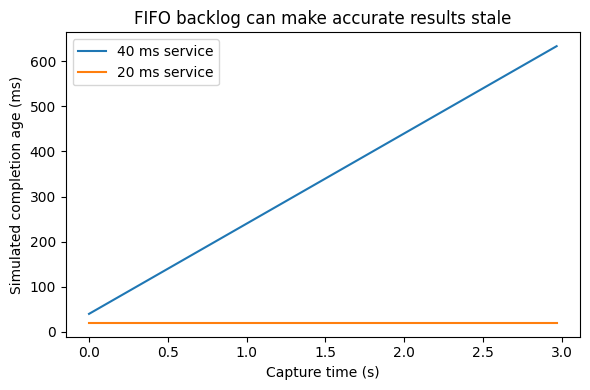

In [4]:
arrival=np.arange(90)/30
service=np.full(len(arrival),.040)
lat=fifo_latencies(arrival,service)
fast=fifo_latencies(arrival,np.full(len(arrival),.020))
assert lat[-1]>lat[0] and np.allclose(fast,.020)
print("Slow-worker simulated age:",summarize_latencies(lat))
print("Fast-worker simulated age:",summarize_latencies(fast))
plt.figure(figsize=(6,4));plt.plot(arrival,lat*1000,label="40 ms service");plt.plot(arrival,fast*1000,label="20 ms service")
plt.xlabel("Capture time (s)");plt.ylabel("Simulated completion age (ms)");plt.title("FIFO backlog can make accurate results stale");plt.legend()
show_and_save(OUT / "simulated_queue_age.png")
save_json(OUT / "results.json",{"evidence":{"CPU":"actual measurements on real reference-derived cloud","queue":"synthetic deterministic FIFO simulation"},"rows":len(cloud),"loop_seconds":loop_s,"array_seconds":array_s,"loop_summary":summarize_latencies(loop_s),"array_summary":summarize_latencies(array_s),"simulated_slow_worker_age":summarize_latencies(lat),"simulated_fast_worker_age":summarize_latencies(fast),"camera_to_display_latency_measured":False,"GPU_inference_measured":False,"ROS2_executed":False})

## Explain before continuing
Which timing boundaries were measured, and which were not? Why must a GPU timer synchronize work at the declared boundary? Why can batching improve throughput while worsening an individual frame's age? What risks arise when a raw point-cloud byte buffer has padding or mixed field types?